In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [33]:
X = np.linspace(0,5,1000).reshape((1000,1)) + 5*np.random.randint(-1,1,(1000,1))
print(X[0:21])
y = X**2 + 2*X + 5
print(y[0:21])
X.shape

[[-5.        ]
 [ 0.00500501]
 [ 0.01001001]
 [-4.98498498]
 [ 0.02002002]
 [ 0.02502503]
 [-4.96996997]
 [ 0.03503504]
 [-4.95995996]
 [-4.95495495]
 [ 0.05005005]
 [ 0.05505506]
 [-4.93993994]
 [-4.93493493]
 [ 0.07007007]
 [ 0.07507508]
 [ 0.08008008]
 [ 0.08508509]
 [ 0.09009009]
 [ 0.0950951 ]
 [ 0.1001001 ]]
[[20.        ]
 [ 5.01003506]
 [ 5.02012022]
 [19.88010533]
 [ 5.04044084]
 [ 5.0506763 ]
 [19.76066156]
 [ 5.07129752]
 [19.68128288]
 [19.6416687 ]
 [ 5.10260511]
 [ 5.11314117]
 [19.52312673]
 [19.48371294]
 [ 5.14504995]
 [ 5.15578642]
 [ 5.16657298]
 [ 5.17740964]
 [ 5.1882964 ]
 [ 5.19923327]
 [ 5.21022023]]


(1000, 1)

Text(0, 0.5, 'y')

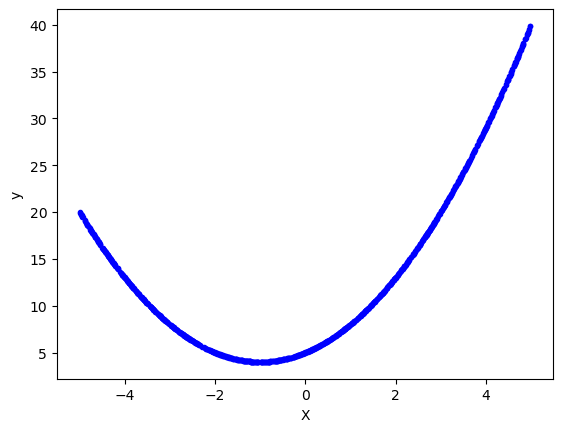

In [34]:
plt.plot(X[:,0],y[:,0],'b.')
plt.xlabel('X')
plt.ylabel('y')

In [54]:
X_2 = np.concatenate((X,X**2),axis = 1)
X_2.shape

(1000, 2)

In [55]:
# Feature normalization
for i in range(X_2.shape[1]):
    mu = np.mean(X_2[:,i],axis=0)
    sigma = np.std(X_2[:,i],axis=0)
    X_2[:,i] = (X_2[:,i]-mu)/sigma
X_2

array([[-1.76140511e+00,  2.31404249e+00],
       [-1.75612969e-03, -1.10058623e+00],
       [ 3.51929797e-06, -1.10058962e+00],
       ...,
       [ 1.75085426e+00,  2.27325756e+00],
       [-5.27542766e-03, -1.10055899e+00],
       [-3.51577867e-03, -1.10057602e+00]])

In [36]:
y_mean = np.mean(y)
y_std = np.std(y)
y = (y-y_mean)/y_std

array([[ 7.42360912e-01],
       [-8.72788437e-01],
       [-8.71701774e-01],
       [ 7.29442416e-01],
       [-8.69512253e-01],
       [-8.68409396e-01],
       [ 7.16572505e-01],
       [-8.66187486e-01],
       [ 7.08019555e-01],
       [ 7.03751177e-01],
       [-8.62814134e-01],
       [-8.61678887e-01],
       [ 6.90978434e-01],
       [ 6.86731649e-01],
       [-8.58240757e-01],
       [-8.57083917e-01],
       [-8.55921678e-01],
       [-8.54754042e-01],
       [-8.53581007e-01],
       [-8.52402575e-01],
       [-8.51218744e-01],
       [-8.50029514e-01],
       [ 6.48753506e-01],
       [ 6.44560704e-01],
       [ 6.40373300e-01],
       [-8.45218615e-01],
       [-8.44002395e-01],
       [-8.42780776e-01],
       [-8.41553759e-01],
       [ 6.19517252e-01],
       [-8.39083531e-01],
       [-8.37840319e-01],
       [-8.36591709e-01],
       [ 6.02929582e-01],
       [ 5.98796160e-01],
       [ 5.94668136e-01],
       [-8.31543288e-01],
       [-8.30267687e-01],
       [-8.2

In [58]:
X_train = np.concatenate((np.ones((X_2.shape[0],1)),X_2),axis=1)
X_train

array([[ 1.00000000e+00, -1.76140511e+00,  2.31404249e+00],
       [ 1.00000000e+00, -1.75612969e-03, -1.10058623e+00],
       [ 1.00000000e+00,  3.51929797e-06, -1.10058962e+00],
       ...,
       [ 1.00000000e+00,  1.75085426e+00,  2.27325756e+00],
       [ 1.00000000e+00, -5.27542766e-03, -1.10055899e+00],
       [ 1.00000000e+00, -3.51577867e-03, -1.10057602e+00]])

In [38]:
def costfunc(X,y,theta):
    m = X.shape[0]
    J = 1/(2*m)*np.sum((X@theta-y)**2)
    J_grad = 1/m*X.T.dot(X.dot(theta)-y)
    return J,J_grad

In [59]:
theta = np.random.rand(3,1)
J_grad = costfunc(X_train,y,theta)

max_iter = 1000
alpha = 0.018 # learning rate
J = np.zeros((max_iter))
for i in range(max_iter):
    J[i],grad = costfunc(X_train,y,theta)
    # print('J=',J[i],'\n')
    # print('grad=',grad,'\n')
    theta = theta - alpha*grad
    # print(theta_new)

print(f'Minimum cost function = {J[-1]:.2f}, at (theta_1,theta_2) = ({theta[0,0]:.2f}, {theta[1,0]:.2f})')

Minimum cost function = 0.00, at (theta_1,theta_2) = (0.00, 0.62)


Text(0, 0.5, 'cost function, J')

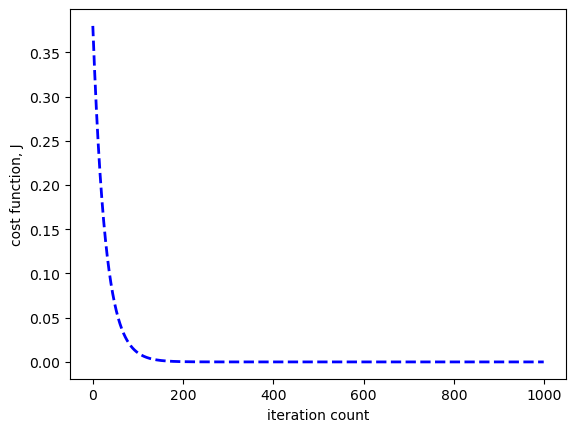

In [60]:
plt.plot(range(max_iter),J,'b--',linewidth = 2)
plt.xlabel('iteration count')
plt.ylabel('cost function, J')

In [61]:
theta

array([[7.92174956e-09],
       [6.19073061e-01],
       [7.92033588e-01]])

In [62]:
prediction = X_train.dot(theta)
prediction

array([[ 7.42360923e-01],
       [-8.72788424e-01],
       [-8.71701761e-01],
       [ 7.29442428e-01],
       [-8.69512240e-01],
       [-8.68409383e-01],
       [ 7.16572516e-01],
       [-8.66187473e-01],
       [ 7.08019566e-01],
       [ 7.03751189e-01],
       [-8.62814121e-01],
       [-8.61678874e-01],
       [ 6.90978445e-01],
       [ 6.86731660e-01],
       [-8.58240744e-01],
       [-8.57083904e-01],
       [-8.55921666e-01],
       [-8.54754029e-01],
       [-8.53580995e-01],
       [-8.52402562e-01],
       [-8.51218731e-01],
       [-8.50029501e-01],
       [ 6.48753518e-01],
       [ 6.44560716e-01],
       [ 6.40373311e-01],
       [-8.45218602e-01],
       [-8.44002382e-01],
       [-8.42780763e-01],
       [-8.41553746e-01],
       [ 6.19517264e-01],
       [-8.39083518e-01],
       [-8.37840306e-01],
       [-8.36591697e-01],
       [ 6.02929594e-01],
       [ 5.98796172e-01],
       [ 5.94668148e-01],
       [-8.31543275e-01],
       [-8.30267674e-01],
       [-8.2

In [45]:
def mse(actual,predict):
    m = actual.shape[0]
    err = (np.sum((actual-predict)**2))/(2*m)
    return err

In [63]:
mserr = mse(y,prediction)
mserr

7.55328576906301e-17

Text(0, 0.5, 'Sale Price (USD)')

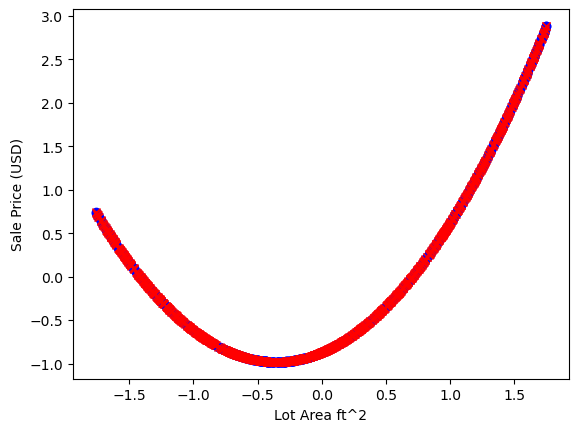

In [64]:
plt.plot(X_train[:,1],y[:,0],'bo')
plt.plot(X_train[:,1],prediction,'rx')
plt.xlabel('Lot Area ft^2')
plt.ylabel('Sale Price (USD)')

(array([461., 144.,  71.,  61.,  61.,  46.,  42.,  41.,  36.,  37.]),
 array([-1.63335290e-08, -1.29827989e-08, -9.63206874e-09, -6.28133863e-09,
        -2.93060851e-09,  4.20121604e-10,  3.77085172e-09,  7.12158184e-09,
         1.04723120e-08,  1.38230421e-08,  1.71737722e-08]),
 <BarContainer object of 10 artists>)

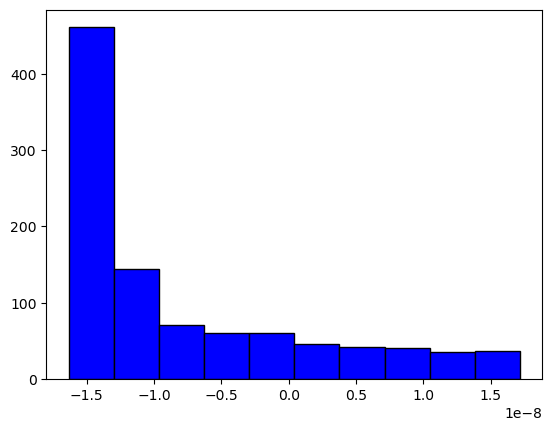

In [65]:
plt.hist(y - prediction, color = 'blue', edgecolor = 'black', bins = 10)

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [32]:
# Split the data into training and testing sets
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)
X_train2

array([[1.0, 3.0820730061880246, -0.4140106134094941, ...,
        -0.07085845399168775, -0.04084185003067663, -0.05004171882244396],
       [1.0, -0.8632973544716135, 1.2337996490753511, ...,
        -0.07085845399168775, -0.04084185003067663, -0.05004171882244396],
       [1.0, 2.3858311778363235, -2.0206256193322183, ...,
        -0.07085845399168775, -0.04084185003067663, -0.05004171882244396],
       ...,
       [1.0, -0.6312167450210466, -0.7435726659064631, ...,
        -0.07085845399168775, -0.04084185003067663, -0.05004171882244396],
       [1.0, -0.8632973544716135, 0.4098945178329286, ...,
        -0.07085845399168775, -0.04084185003067663, -0.05004171882244396],
       [1.0, 0.5291863022317882, 0.4098945178329286, ...,
        -0.07085845399168775, -0.04084185003067663, -0.05004171882244396]],
      dtype=object)

In [35]:
print(X_train2.shape)
print(X_test2.shape)

(960, 24)
(241, 24)


In [36]:
# Create a linear regression model
model = LinearRegression()

# Train the model on the training data
model.fit(X_train2, y_train2)

# Make predictions on the test data
y_pred = model.predict(X_test2)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test2, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.30376127331597336


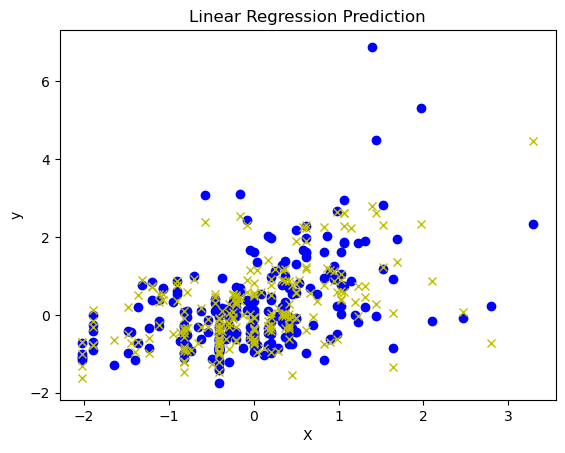

In [38]:
# Visualize the results
plt.plot(X_test2[:,2], y_test2, 'bo')
plt.plot(X_test2[:,2], y_pred, 'yx', linewidth=3)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Prediction')
plt.show()

In [39]:
# Make predictions on the test data
prediction2 = model.predict(X_train2)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_train2, prediction2)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.24619782966553416


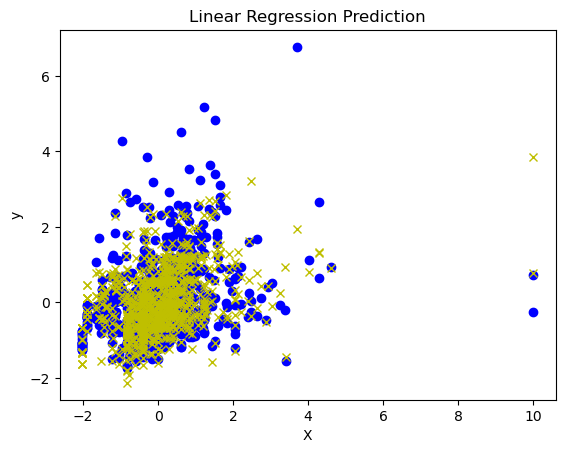

In [41]:
# Visualize the results
plt.plot(X_train2[:,2], y_train2, 'bo')
plt.plot(X_train2[:,2], prediction2, 'yx', linewidth=3)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Prediction')
plt.show()

In [49]:
X = X.astype('float64')

In [50]:
paras = np.linalg.inv(X.T@X)@(X.T@y)
paras

array([[ 2.28983499e-16],
       [-1.27075118e-02],
       [ 6.26088661e-02],
       [ 1.23702618e-01],
       [ 4.24269339e-01],
       [ 1.98648296e-02],
       [ 1.49865089e-01],
       [ 4.12033692e-02],
       [-4.68750000e-02],
       [-9.37500000e-02],
       [-3.90625000e-02],
       [-1.25000000e-01],
       [-1.56250000e-01],
       [ 1.25000000e-01],
       [ 1.87500000e-01],
       [ 1.25000000e-01],
       [-5.46875000e-02],
       [-9.37500000e-02],
       [-3.75000000e-01],
       [ 7.03125000e-02],
       [ 5.07812500e-02],
       [ 2.73437500e-02],
       [ 3.90625000e-03],
       [ 2.53906250e-02]])

In [54]:
prediction3 = X@paras
prediction3

array([[ 0.64731883],
       [-0.17144576],
       [ 0.70996616],
       ...,
       [ 1.25135583],
       [-0.73335397],
       [-0.13341761]])

In [56]:
mserr = np.sum((y-prediction3)**2)/(2*y.shape[0])
mserr

0.13414397428481867

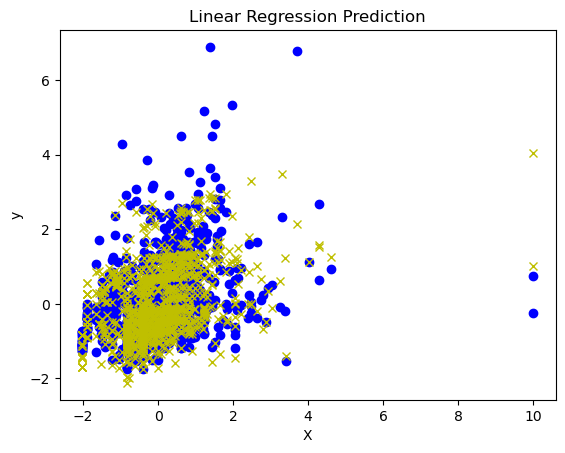

In [57]:
# Visualize the results
plt.plot(X[:,2], y, 'bo')
plt.plot(X[:,2], prediction3, 'yx', linewidth=3)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Prediction')
plt.show()